In [1]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.io import wavfile
from IPython.display import Audio, display
import warnings
from scipy.signal import hilbert
warnings.filterwarnings('ignore')


audio_df = pd.read_csv("../data/qualidade_audios.csv")
display(audio_df)

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio
0,-89_5bDU5ko.mp3,54.566896,48000,0.087395,0.848866,0.102955,28.500414,0.068936,3
1,LPDJollYuAc.mp3,12.968354,48000,0.290967,1.135026,0.256353,48.810177,0.022853,0
2,zu1dIUoGd1g.mp3,706.880000,48000,0.044159,0.544028,0.081170,31.315220,0.075895,19
3,0DQ82ua1GqQ.mp3,53.487167,48000,0.103145,0.984857,0.104731,37.229790,0.035058,0
4,q2LIyyDKeOU.mp3,60.000979,48000,0.131033,1.044674,0.125430,51.049328,0.042408,0
...,...,...,...,...,...,...,...,...,...
8968,AN4cFw5rBBU.mp3,37.848979,48000,0.061322,0.792349,0.077393,26.758072,0.031574,4
8969,pUfLK1jrglg.mp3,85.844188,48000,0.030217,0.389398,0.077599,34.001556,0.018390,1
8970,63lBbV42njg.mp3,45.708500,48000,0.104041,1.014510,0.102553,27.954025,0.061560,0
8971,1jOpENTEC4A.mp3,4715.067229,48000,0.048428,0.990683,0.048883,32.209175,0.040369,861


- Estudando a duração dos vídeos

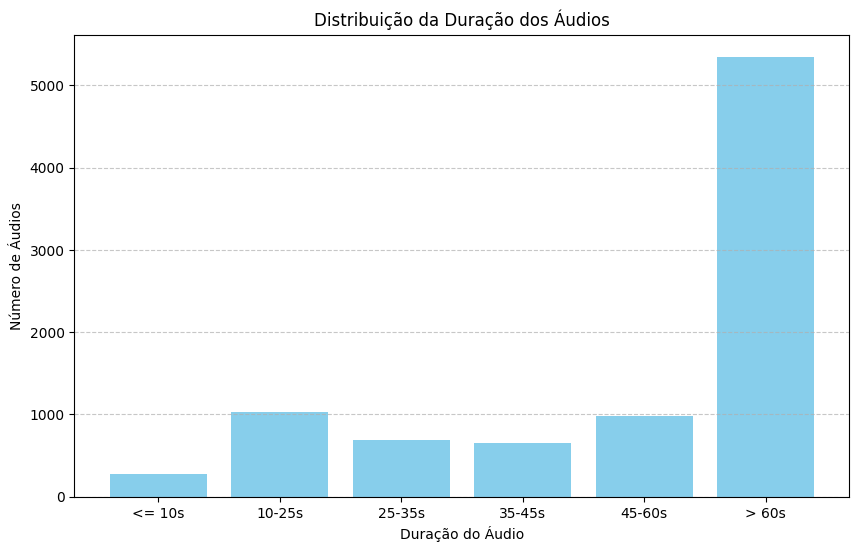

In [2]:
bins = [0, 10, 25, 35, 45, 60, float('inf')]
labels = ['0-10s', '10-25s', '25-35s', '35-45s', '45-60s', '>60s']
audio_df['duracao_categoria'] = pd.cut(audio_df['duracao_segundos'], bins=bins, labels=labels, right=True)
category_counts = audio_df['duracao_categoria'].value_counts().sort_index()

thresholds = [10, 25, 35, 45, 60]
counts = []
labels_for_plot = []

for i, threshold in enumerate(thresholds):
    if i == 0:
        count = audio_df[audio_df['duracao_segundos'] <= threshold].shape[0]
        label = f'<= {threshold}s'
    else:
        prev_threshold = thresholds[i-1]
        count = audio_df[(audio_df['duracao_segundos'] > prev_threshold) & (audio_df['duracao_segundos'] <= threshold)].shape[0]
        label = f'{prev_threshold}-{threshold}s'
    counts.append(count)
    labels_for_plot.append(label)

count_gt_60 = audio_df[audio_df['duracao_segundos'] > 60].shape[0]
counts.append(count_gt_60)
labels_for_plot.append('> 60s')


plt.figure(figsize=(10, 6))
plt.bar(labels_for_plot, counts, color='skyblue')
plt.xlabel('Duração do Áudio')
plt.ylabel('Número de Áudios')
plt.title('Distribuição da Duração dos Áudios')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [3]:
ids_dezsec = audio_df[audio_df['duracao_segundos'] <= 10]['arquivo'].tolist()

for i,id in enumerate(ids_dezsec):
    ids_dezsec[i] = id.replace('.mp3','')

df_ids = pd.DataFrame(ids_dezsec, columns=['ID_Audio'])
df_ids.to_csv('ids_audios_curtos.csv', index=False)

In [4]:
#Removendo os áudios com menos de 10 segundos
index_dezsec = audio_df[audio_df['duracao_segundos'] <= 10]['arquivo'].index
df_limpo = audio_df.drop(index_dezsec).copy()

- Estratificando o dataframe pelas regiões de silêncio

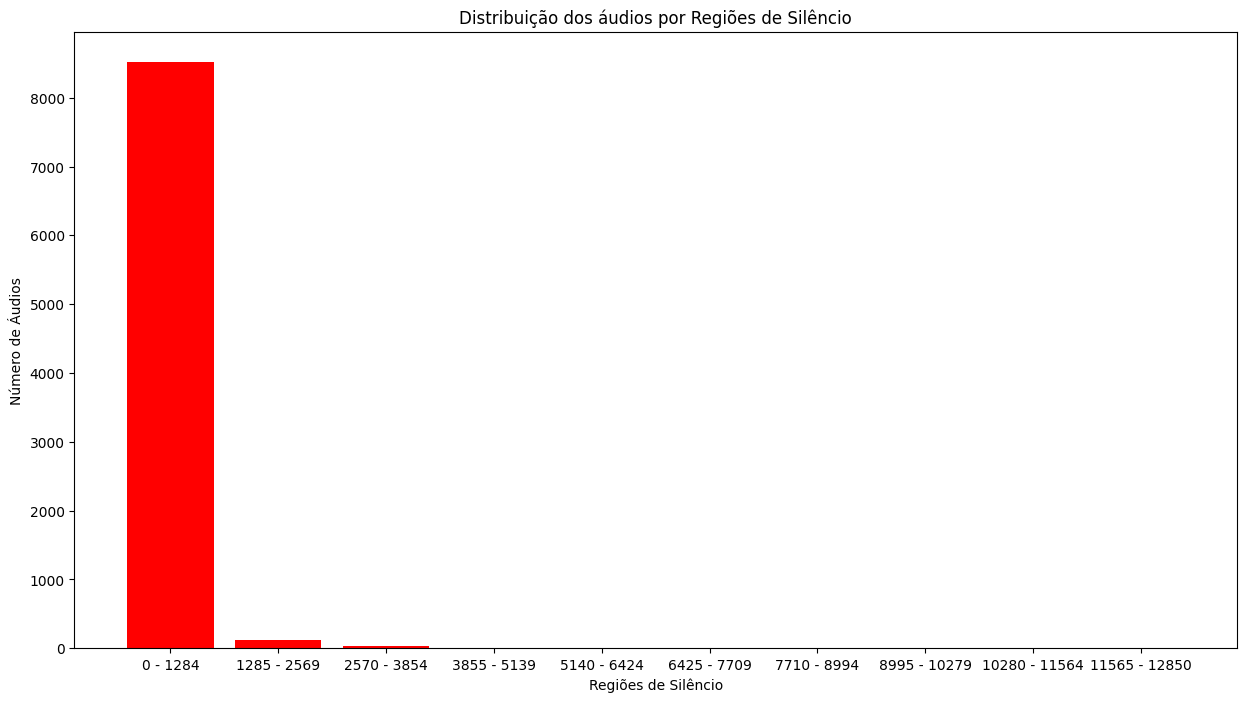

In [5]:
max_silencio = max(df_limpo['regioes_silencio'])
num_bar = 10 #Quantas barras terá o gráfico

labels = []
bin_range = int(max_silencio/num_bar) #o tamanho do intervalo de cada barra
bins = [i * bin_range for i in range(num_bar)]
bins.append(max_silencio + 1)

for i in range(num_bar):
    lower_bound = bins[i] #o início de cada intervalo
    upper_bound = (bins[i+1] - 1) if i<(num_bar-1) else max_silencio #o fim de cada intervalo
    labels.append(f"{lower_bound} - {upper_bound}") #o início-fim de cada barra, baseado no tamanho dos intervalos

bin_silencio = pd.cut(df_limpo['regioes_silencio'], bins=bins, labels=labels, right=False, include_lowest=True) #de qual intervalo cada texto faz parte
counts_bin = bin_silencio.value_counts().sort_index()

plt.figure(figsize=(15, 8))
plt.bar(labels, counts_bin, color="red")
plt.xlabel('Regiões de Silêncio')
plt.ylabel('Número de Áudios')
plt.title('Distribuição dos áudios por Regiões de Silêncio')
plt.show()

- Estratificando a primeira barra do gráfico anterior

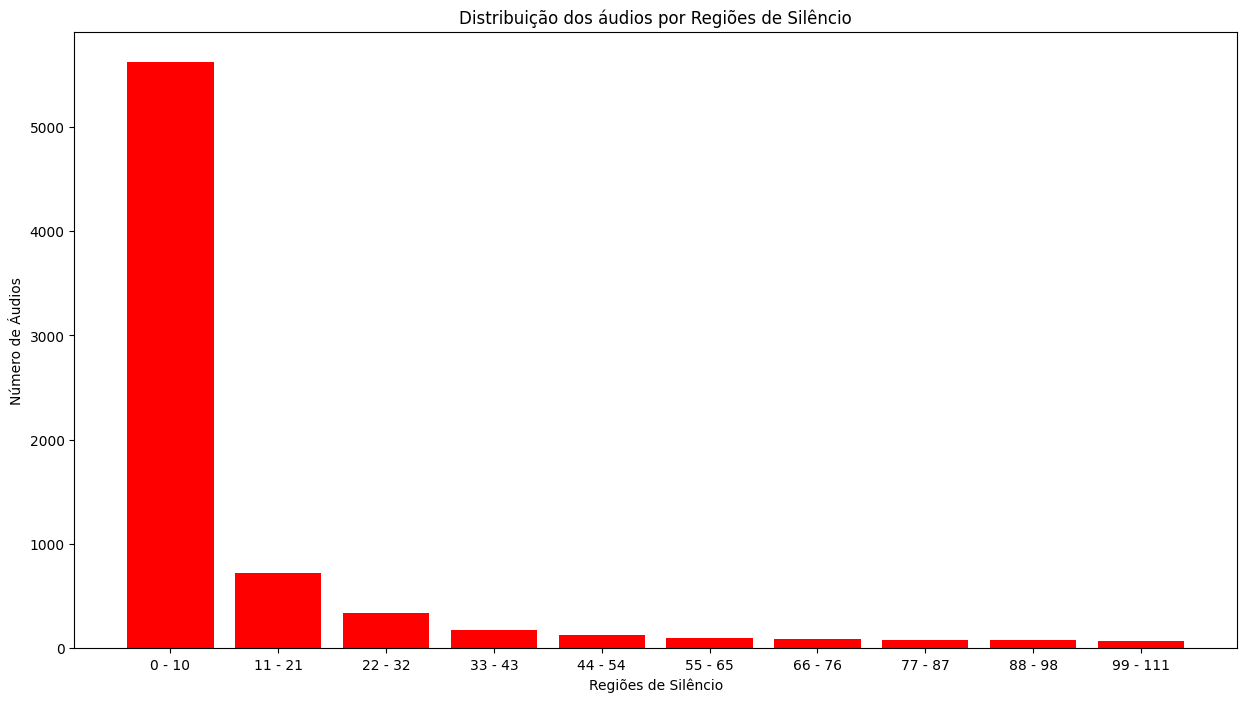

In [6]:
max_silencio = 111
num_bar = 10 #Quantas barras terá o gráfico

labels = []
bin_range = int(max_silencio/num_bar) #o tamanho do intervalo de cada barra
bins = [i * bin_range for i in range(num_bar)]
bins.append(max_silencio + 1)

for i in range(num_bar):
    lower_bound = bins[i] #o início de cada intervalo
    upper_bound = (bins[i+1] - 1) if i<(num_bar-1) else max_silencio #o fim de cada intervalo
    labels.append(f"{lower_bound} - {upper_bound}") #o início-fim de cada barra, baseado no tamanho dos intervalos

bin_silencio = pd.cut(df_limpo['regioes_silencio'], bins=bins, labels=labels, right=False, include_lowest=True) #de qual intervalo cada texto faz parte
counts_bin = bin_silencio.value_counts().sort_index()

plt.figure(figsize=(15, 8))
plt.bar(labels, counts_bin, color="red")
plt.xlabel('Regiões de Silêncio')
plt.ylabel('Número de Áudios')
plt.title('Distribuição dos áudios por Regiões de Silêncio')
plt.show()

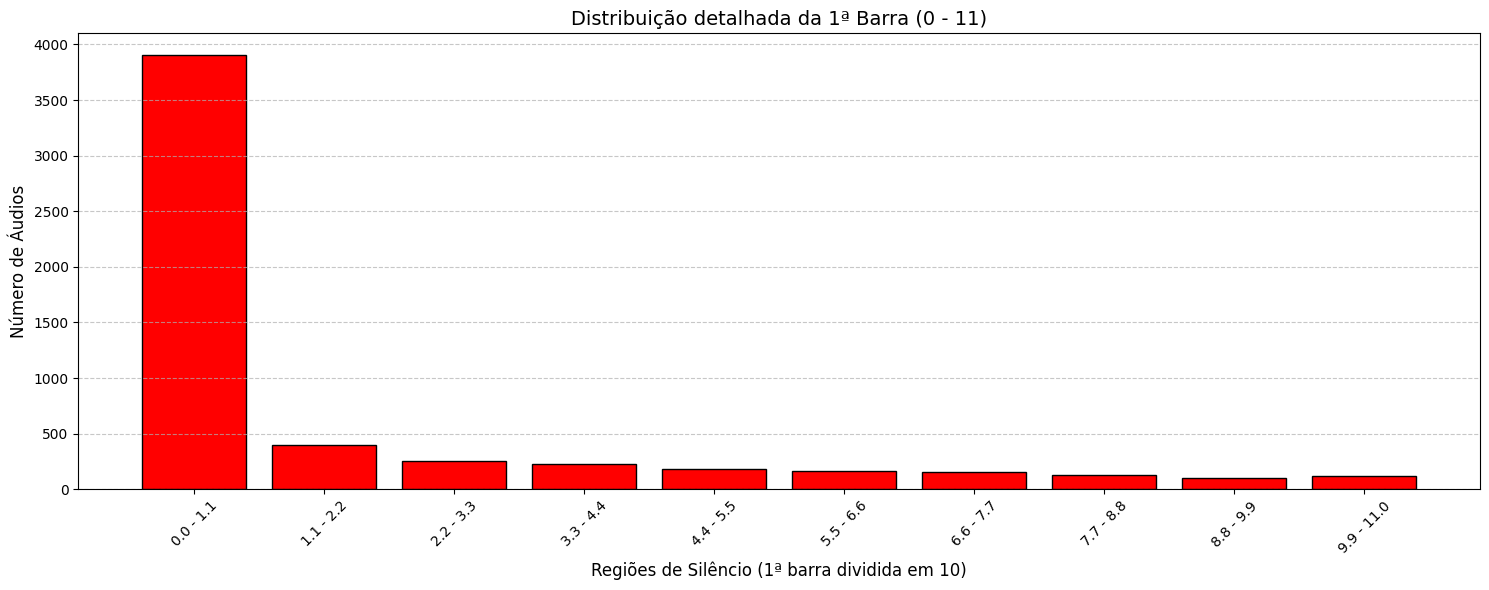

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Etapa 1: Criar as barras gerais
max_silencio = 111
num_bar = 10
bin_range = int(max_silencio / num_bar)
bins = [i * bin_range for i in range(num_bar)]
bins.append(max_silencio + 1)

labels = []
for i in range(num_bar):
    lower_bound = bins[i]
    upper_bound = (bins[i+1] - 1) if i < (num_bar - 1) else max_silencio
    labels.append(f"{lower_bound} - {upper_bound}")

# Etapa 2: Filtrar dados da primeira barra
li_primeira_barra = bins[0]
ls_primeira_barra = bins[1]
audios_primeira_barra = df_limpo[
    (df_limpo['regioes_silencio'] >= li_primeira_barra) &
    (df_limpo['regioes_silencio'] < ls_primeira_barra)
]

# Etapa 3: Dividir o intervalo da primeira barra em 10 sub-barras
sub_num_bar = 10
sub_bin_range = (ls_primeira_barra - li_primeira_barra) / sub_num_bar
sub_bins = [li_primeira_barra + i * sub_bin_range for i in range(sub_num_bar + 1)]

sub_labels = []
for i in range(sub_num_bar):
    lower = sub_bins[i]
    upper = sub_bins[i+1]
    sub_labels.append(f"{lower:.1f} - {upper:.1f}")

# Classificar os dados da primeira barra em sub-barras
bin_sub = pd.cut(
    audios_primeira_barra['regioes_silencio'],
    bins=sub_bins,
    labels=sub_labels,
    right=False,
    include_lowest=True
)
counts_sub = bin_sub.value_counts().sort_index()

# Etapa 4: Plotar
plt.figure(figsize=(15, 6))
plt.bar(sub_labels, counts_sub, color='red', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Regiões de Silêncio (1ª barra dividida em 10)', fontsize=12)
plt.ylabel('Número de Áudios', fontsize=12)
plt.title(f'Distribuição detalhada da 1ª Barra ({li_primeira_barra} - {ls_primeira_barra})', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


- Plotando Distribuição de Áudios por Proporção de Silêncio/Tempo

In [8]:
df_limpo["silencio/tempo"].describe()

KeyError: 'silencio/tempo'

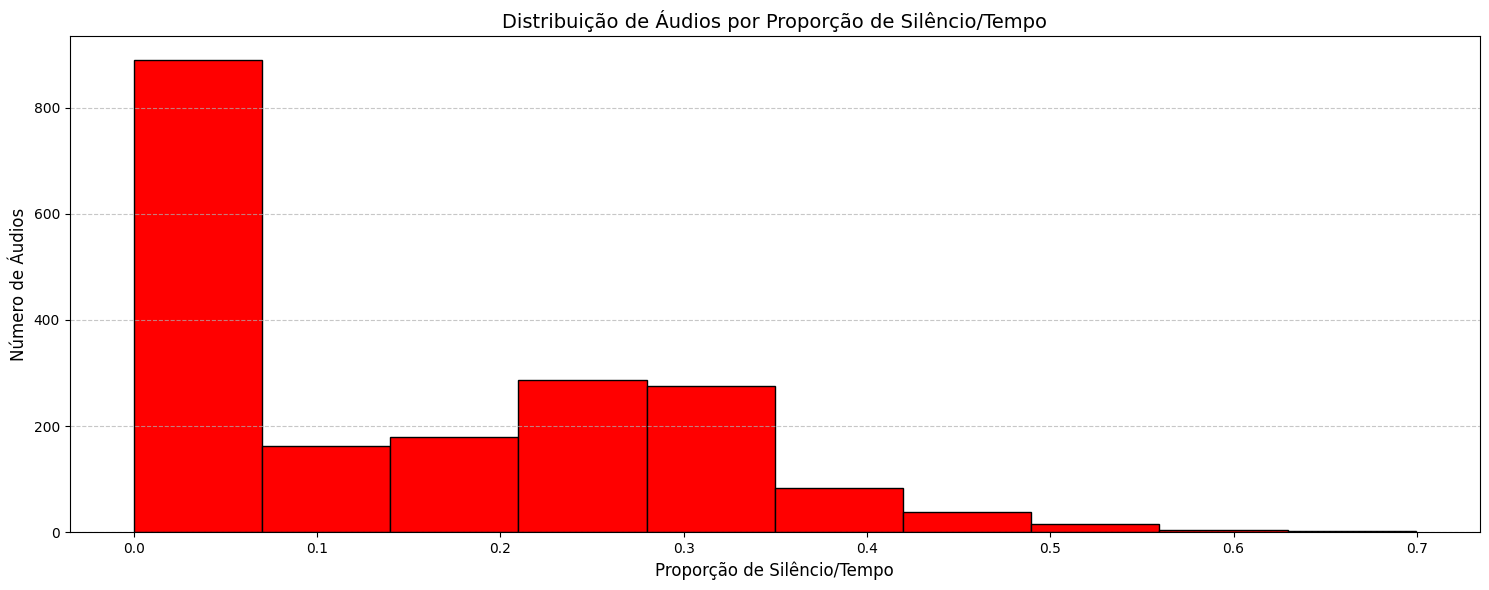

In [ ]:
df_limpo['silencio/tempo'] = df_limpo['regioes_silencio'] / df_limpo['duracao_segundos']

plt.figure(figsize=(15, 6))
n, bins_edges, patches = plt.hist(df_limpo['silencio/tempo'], bins=10, color='red', edgecolor='black')

plt.xlabel('Proporção de Silêncio/Tempo', fontsize=12)
plt.ylabel('Número de Áudios', fontsize=12)
plt.title('Distribuição de Áudios por Proporção de Silêncio/Tempo', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

- Plotando Distribuição de Áudios na Primeira Barra do gráfico anterior

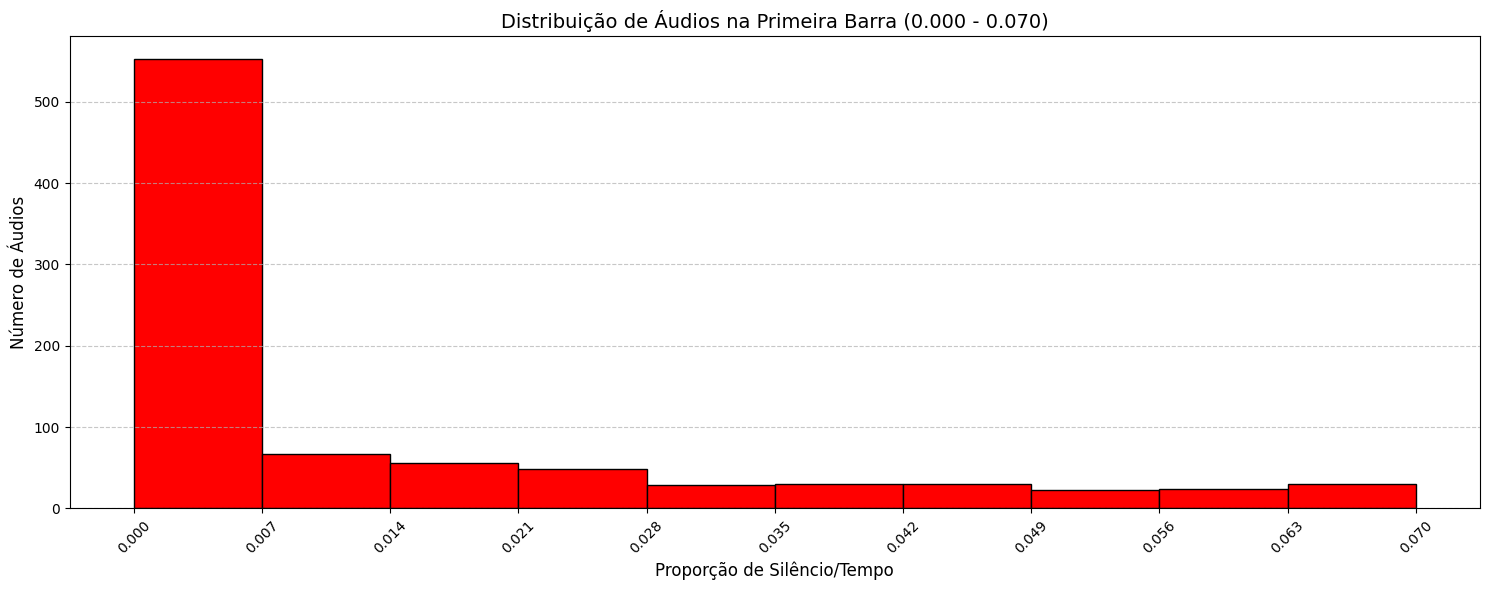

In [ ]:
import matplotlib.pyplot as plt

# Pegando as bordas da primeira barra
li_primeira_barra = bins_edges[0]
ls_primeira_barra = bins_edges[1]

# Filtrando os dados que pertencem à primeira barra
audios_na_primeira_barra = df_limpo[
    (df_limpo['silencio/tempo'] >= li_primeira_barra) & 
    (df_limpo['silencio/tempo'] < ls_primeira_barra)
]

# Plotando o histograma se houver dados
plt.figure(figsize=(15, 6))
if not audios_na_primeira_barra.empty:
    # Criando o histograma com 10 bins dentro da faixa da primeira barra
    n, bins, patches = plt.hist(
        audios_na_primeira_barra['silencio/tempo'],
        bins=10,
        color='red',
        edgecolor='black'
    )

    # Ajustando os rótulos dos ticks do eixo X para mostrar as bordas dos bins
    plt.xticks(bins, [f'{b:.3f}' for b in bins], rotation=45)

    plt.xlabel('Proporção de Silêncio/Tempo', fontsize=12)
    plt.ylabel('Número de Áudios', fontsize=12)
    plt.title(f'Distribuição de Áudios na Primeira Barra ({li_primeira_barra:.3f} - {ls_primeira_barra:.3f})', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Não há dados na primeira barra para criar um histograma.")

# Salvando os dados filtrados
audios_na_primeira_barra.to_csv('ids_audios_sil_temp.csv', index=False)


In [ ]:
audios_na_primeira_barra_2 = audios_na_primeira_barra[audios_na_primeira_barra['silencio/tempo'] <= 0.007]
audios_na_primeira_barra_2

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,duracao_categoria,silencio/tempo
5,hEPS5wpurkM.mp3,66.850249,44100,0.104044,0.962973,0.108045,136.467381,0.061401,0,>60s,0.000000
13,t0OEDe-h7Ew.mp3,866.127542,48000,0.066992,1.013549,0.066096,27.605300,0.062524,1,>60s,0.001155
14,RTekEjC4Nps.mp3,22.101333,48000,0.225782,1.193549,0.189169,31.268148,0.056754,0,10-25s,0.000000
16,GC2LRe0U5E8.mp3,51.525083,48000,0.005913,0.095428,0.061964,25.371423,0.116954,0,45-60s,0.000000
17,tMXTbckeQ-0.mp3,12.306583,48000,0.115580,0.940625,0.122876,53.294010,0.052152,0,10-25s,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
1946,I8cEhFOdeSs.mp3,879.304854,48000,0.128297,1.205748,0.106404,27.656891,0.033146,0,>60s,0.000000
1948,bDGBT2VKXx0.mp3,135.808000,48000,0.014452,0.229142,0.063070,23.983972,0.043809,0,>60s,0.000000
1950,dX4rqi4_iss.mp3,14.464000,48000,0.188685,1.164248,0.162066,60.525055,0.076055,0,10-25s,0.000000
1952,kN3p6HIfW3Y.mp3,75.209438,48000,0.137584,1.105482,0.124456,66.339850,0.043569,0,>60s,0.000000


In [ ]:
for nome in audios_na_primeira_barra_2['arquivo'].to_list():
    nome = nome[:-4]
    with open(f'/home/webmedia2025/project/2etapa/transcriptions/{nome}.txt', 'r') as f:
        print(f.read())
        print('-----------------------')

 verschiedência de siowan Comenrive Poss湘
-----------------------
 Vamos ver se ele continua aqui na distribuição. Segunda rodada. Terceira rodada. Solta uma carta. Se ela apertar, nós aqui batemos o nosso stop queen. Na bet de R$ 2. Vamos ver se ele fecha essa laranja. Olá! Sejam todos muito bem-vindos ao canal A Verdade das Slots. E no vídeo de hoje nós vamos dar continuidade à nossa série maravilhosa do 100 aos 1000 reais. Nós vamos fazendo aqui uma série maravilhosa. Você que está acompanhando o nosso canal, está vendo aqui uma série muito boa com jogadas, com frequências e subindo a banca para os 1000 reais. Vem comigo! Você que ainda não é inscrito em nosso canal, aproveite e se inscreva em nosso canal. Ative o sininho para que o YouTube possa te notificar assim que gravarmos um vídeo. Também deixa aquele like maravilhoso. Não se esqueça de comentar no nosso canal o que você está sentindo dessa nova série maravilhosa que estamos entregando para você nesse canal A Verdade das Slot

In [ ]:
audios_na_primeira_barra_2['silencio/tempo'].value_counts()

silencio/tempo
0.000000    427
0.008775      7
0.003131      5
0.003296      4
0.016666      2
           ... 
0.004901      1
0.066774      1
0.007533      1
0.006503      1
0.004745      1
Name: count, Length: 441, dtype: int64

In [ ]:
audios_na_primeira_barra_2['silencio/tempo'].describe()

count    890.000000
mean       0.012593
std        0.019018
min        0.000000
25%        0.000000
50%        0.001554
75%        0.019331
max        0.069754
Name: silencio/tempo, dtype: float64

- Plotando amplitude_ratio (mean/max) dos dataframes separados entre os áudios pela proporção silêncio/tempo

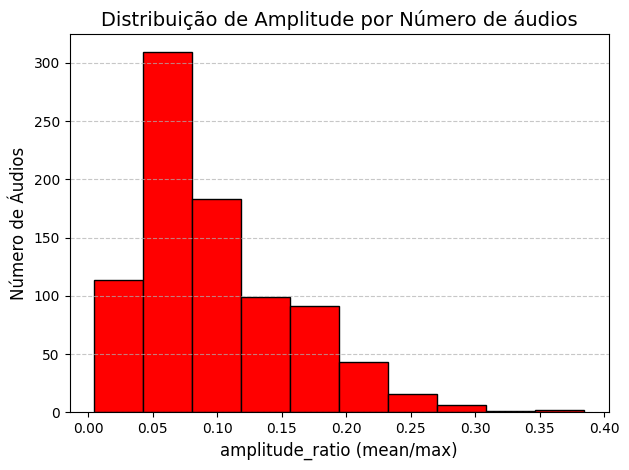

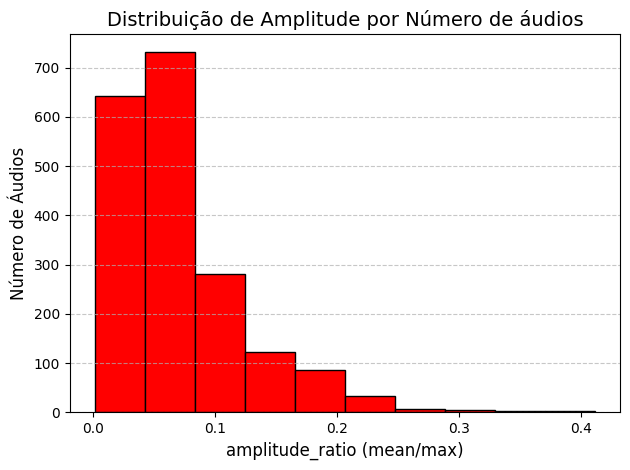

In [ ]:
plt.hist(audios_na_primeira_barra['amplitude_ratio (mean/max)'], bins=10, color='red', edgecolor='black')
plt.xlabel('amplitude_ratio (mean/max)', fontsize=12)
plt.ylabel('Número de Áudios', fontsize=12)
plt.title(f'Distribuição de Amplitude por Número de áudios', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

arquivos_aux = audios_na_primeira_barra['arquivo'].tolist()
df_aux = df_limpo[~df_limpo['arquivo'].isin(arquivos_aux)]

plt.hist(df_limpo['amplitude_ratio (mean/max)'], bins=10, color='red', edgecolor='black')
plt.xlabel('amplitude_ratio (mean/max)', fontsize=12)
plt.ylabel('Número de Áudios', fontsize=12)
plt.title(f'Distribuição de Amplitude por Número de áudios', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()